# Sistem Pendukung Keputusan Pemilihan Tempat Wisata
## Menggunakan Metode *Profile Matching*

> **Referensi:** Muhaimin, F.A., dkk. (2018). *Sistem Pendukung Keputusan Pemilihan Obyek Wisata
> di Kota Balikpapan Menggunakan Metode Profile Matching*. JURTI Vol.2 No.1, Universitas Mulawarman.
> Universitas Mulawarman. DOI: 10.30872/jurti.v2i1.1427

---

## 1. Latar Belakang

Metode **Profile Matching** adalah mekanisme pengambilan keputusan dengan mengasumsikan bahwa
terdapat tingkat variabel prediktor ideal yang harus dipenuhi oleh subyek yang diteliti.
Setiap alternatif dibandingkan terhadap profil ideal untuk menghasilkan **ranking**.

---

## 2. Kriteria & Skala Nilai

| No | Kriteria | Faktor | Skala 1 | Skala 2 | Skala 3 | Skala 4 | Skala 5 |
|----|----------|--------|---------|---------|---------|---------|----------|
| 1 | **Biaya** | Core | ≤ Rp100rb | Rp100–200rb | Rp200–400rb | Rp400–500rb | ≥ Rp500rb |
| 2 | **Fasilitas** | Core | Makan+Belanja+Lengkap | Makan+Belanja | Tempat Makan | Santai/Duduk | Tidak Ada |
| 3 | **Jenis Wisata** | Secondary | Alam+Pertunjukan+Kuliner+Belanja | Pertunjukan+Kuliner+Belanja | Alam+Kuliner+Belanja | Alam+Kuliner | Alam Saja |
| 4 | **Jarak** | Secondary | ≤ 5 km | 5–10 km | 10–30 km | 30–50 km | ≥ 50 km |

**Bobot:** Core Factor = **60%** | Secondary Factor = **40%**

---

## 3. Profil Ideal Wisatawan

| Kriteria | Nilai Ideal | Keterangan |
|----------|-------------|------------|
| Biaya | **1** | Biaya ≤ Rp100rb |
| Fasilitas | **2** | Ada tempat makan + belanja |
| Jenis Wisata | **2** | Pertunjukan + Kuliner + Belanja |
| Jarak | **3** | Jarak 10–30 km |

---

## 4. Tahapan Perhitungan


### Langkah 1 — Import Library


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

print(" Library berhasil diimport")

 Library berhasil diimport


### Langkah 2 — Tabel Konversi Bobot GAP

Setiap nilai GAP dikonversi ke bobot sesuai tabel standar Kusrini (2007):

| Selisih GAP | Bobot | Keterangan |
|:-----------:|:-----:|------------|
| 0 | 5 | Kompetensi sesuai dengan yang dibutuhkan |
| 1 | 4.5 | Kelebihan 1 tingkat |
| -1 | 4 | Kekurangan 1 tingkat |
| 2 | 3.5 | Kelebihan 2 tingkat |
| -2 | 3 | Kekurangan 2 tingkat |
| 3 | 2.5 | Kelebihan 3 tingkat |
| -3 | 2 | Kekurangan 3 tingkat |
| 4 | 1.5 | Kelebihan 4 tingkat |
| -4 | 1 | Kekurangan 4 tingkat |


In [2]:
bobot_gap = {
     0:  5,
     1:  4.5,
    -1:  4,
     2:  3.5,
    -2:  3,
     3:  2.5,
    -3:  2,
     4:  1.5,
    -4:  1
}

df_bobot_gap = pd.DataFrame(
    [(gap, bobot, "Tidak ada selisih" if gap == 0 else
      f"Kelebihan {abs(gap)} tingkat" if gap > 0 else
      f"Kekurangan {abs(gap)} tingkat")
     for gap, bobot in bobot_gap.items()],
    columns=["Selisih (GAP)", "Bobot Nilai", "Keterangan"]
)
print(" TABEL KONVERSI BOBOT GAP")
print("=" * 45)
print(df_bobot_gap.to_string(index=False))

 TABEL KONVERSI BOBOT GAP
 Selisih (GAP)  Bobot Nilai           Keterangan
             0          5.0    Tidak ada selisih
             1          4.5  Kelebihan 1 tingkat
            -1          4.0 Kekurangan 1 tingkat
             2          3.5  Kelebihan 2 tingkat
            -2          3.0 Kekurangan 2 tingkat
             3          2.5  Kelebihan 3 tingkat
            -3          2.0 Kekurangan 3 tingkat
             4          1.5  Kelebihan 4 tingkat
            -4          1.0 Kekurangan 4 tingkat


### Langkah 3 — Input Data Profil Wisatawan & Obyek Wisata

Masukkan nilai setiap obyek wisata sesuai skala pada tabel kriteria di atas.
Ubah bagian `tempat_wisata` untuk mengganti data sesuai kebutuhan.


In [3]:
profil_ideal = {
    "biaya":     1,
    "fasilitas": 2,
    "jenis":     2,
    "jarak":     3
}

tempat_wisata = {
    "Pantai Manggar": {
        "biaya": 1, "fasilitas": 2, "jenis": 2, "jarak": 3
    },
    "Kebun Raya Balikpapan": {
        "biaya": 2, "fasilitas": 3, "jenis": 1, "jarak": 4
    },
    "Pantai Lamaru": {
        "biaya": 1, "fasilitas": 3, "jenis": 2, "jarak": 4
    },
    "Bukit Bangkirai": {
        "biaya": 3, "fasilitas": 4, "jenis": 1, "jarak": 5
    },
    "Caribbean Island Waterpark": {
        "biaya": 4, "fasilitas": 1, "jenis": 3, "jarak": 2
    }
}

core_factor      = ["biaya", "fasilitas"]
secondary_factor = ["jenis", "jarak"]
bobot_cf = 0.6
bobot_sf = 0.4

kriteria_list = list(profil_ideal.keys())

print("👤 PROFIL IDEAL WISATAWAN")
print("=" * 35)
for k, v in profil_ideal.items():
    print(f"   {k.capitalize():<12}: {v}")

print("\nDATA TEMPAT WISATA")
print("=" * 35)
df_input = pd.DataFrame(tempat_wisata).T
df_input.index.name = "Tempat Wisata"
print(df_input.to_string())

👤 PROFIL IDEAL WISATAWAN
   Biaya       : 1
   Fasilitas   : 2
   Jenis       : 2
   Jarak       : 3

DATA TEMPAT WISATA
                            biaya  fasilitas  jenis  jarak
Tempat Wisata                                             
Pantai Manggar                  1          2      2      3
Kebun Raya Balikpapan           2          3      1      4
Pantai Lamaru                   1          3      2      4
Bukit Bangkirai                 3          4      1      5
Caribbean Island Waterpark      4          1      3      2


### Langkah 4 — Fungsi Perhitungan

Definisi fungsi-fungsi yang digunakan dalam perhitungan Profile Matching:

**a. Rumus GAP**
$$GAP = \text{Profil Wisatawan} - \text{Profil Obyek Wisata}$$

**b. Rumus Core Factor (NCF)**
$$NCF = \frac{\sum NC}{\sum IC}$$
- $NC$ = Jumlah total nilai bobot core factor
- $IC$ = Jumlah item core factor

**c. Rumus Secondary Factor (NSF)**
$$NSF = \frac{\sum NS}{\sum IS}$$
- $NS$ = Jumlah total nilai bobot secondary factor
- $IS$ = Jumlah item secondary factor

**d. Rumus Nilai Total**
$$N = (60\% \times NCF) + (40\% \times NSF)$$


**Fungsi Perhitungan Profile Matching**

In [4]:
def hitung_gap(nilai_ideal, nilai_alternatif):
    """Menghitung selisih GAP: profil ideal - nilai alternatif"""
    return nilai_ideal - nilai_alternatif

def konversi_bobot(gap):
    """Mengkonversi nilai GAP ke bobot berdasarkan tabel konversi"""
    return bobot_gap.get(gap, 0)

def hitung_ncf(bobot_dict, cf_list):
    """Menghitung Nilai Core Factor (NCF)"""
    nilai = [bobot_dict[k] for k in cf_list]
    return sum(nilai) / len(nilai)

def hitung_nsf(bobot_dict, sf_list):
    """Menghitung Nilai Secondary Factor (NSF)"""
    nilai = [bobot_dict[k] for k in sf_list]
    return sum(nilai) / len(nilai)

def hitung_nilai_total(ncf, nsf, pct_cf=0.6, pct_sf=0.4):
    """Menghitung Nilai Total akhir"""
    return (pct_cf * ncf) + (pct_sf * nsf)

print("✅ Fungsi-fungsi perhitungan berhasil didefinisikan")

✅ Fungsi-fungsi perhitungan berhasil didefinisikan


### Langkah 5 — Perhitungan Nilai GAP dan Bobot GAP

Hitung selisih antara profil wisatawan dan profil ideal, lalu konversi ke bobot.


In [5]:
rows_gap   = []
rows_bobot = []

for nama, profil in tempat_wisata.items():
    row_gap   = {"Tempat Wisata": nama}
    row_bobot = {"Tempat Wisata": nama}
    for k in kriteria_list:
        gap = hitung_gap(profil_ideal[k], profil[k])
        row_gap[f"GAP {k.capitalize()}"]   = gap
        row_bobot[f"Bobot {k.capitalize()}"] = konversi_bobot(gap)
    rows_gap.append(row_gap)
    rows_bobot.append(row_bobot)

df_gap   = pd.DataFrame(rows_gap).set_index("Tempat Wisata")
df_bobot = pd.DataFrame(rows_bobot).set_index("Tempat Wisata")

print(" TABEL NILAI GAP (Profil Ideal - Nilai Tempat Wisata)")
print("=" * 60)
print(df_gap.to_string())
print()
print(" TABEL BOBOT GAP (Hasil Konversi)")
print("=" * 60)
print(df_bobot.to_string())

 TABEL NILAI GAP (Profil Ideal - Nilai Tempat Wisata)
                            GAP Biaya  GAP Fasilitas  GAP Jenis  GAP Jarak
Tempat Wisata                                                             
Pantai Manggar                      0              0          0          0
Kebun Raya Balikpapan              -1             -1          1         -1
Pantai Lamaru                       0             -1          0         -1
Bukit Bangkirai                    -2             -2          1         -2
Caribbean Island Waterpark         -3              1         -1          1

 TABEL BOBOT GAP (Hasil Konversi)
                            Bobot Biaya  Bobot Fasilitas  Bobot Jenis  Bobot Jarak
Tempat Wisata                                                                     
Pantai Manggar                        5              5.0          5.0          5.0
Kebun Raya Balikpapan                 4              4.0          4.5          4.0
Pantai Lamaru                         5              4

### Langkah 6 — Perhitungan NCF, NSF, dan Nilai Total

| Kelompok | Kriteria | Bobot |
|----------|----------|-------|
| **Core Factor** | Biaya, Fasilitas | 60% |
| **Secondary Factor** | Jenis Wisata, Jarak | 40% |


In [6]:
hasil = []

for nama, profil in tempat_wisata.items():
    bobot_dict = {}
    for k in kriteria_list:
        gap = hitung_gap(profil_ideal[k], profil[k])
        bobot_dict[k] = konversi_bobot(gap)

    ncf         = hitung_ncf(bobot_dict, core_factor)
    nsf         = hitung_nsf(bobot_dict, secondary_factor)
    nilai_total = hitung_nilai_total(ncf, nsf, bobot_cf, bobot_sf)

    hasil.append({
        "Tempat Wisata": nama,
        "NCF": round(ncf, 2),
        "NSF": round(nsf, 2),
        "Nilai Total": round(nilai_total, 2)
    })

df_hasil = pd.DataFrame(hasil).sort_values(
    "Nilai Total", ascending=False
).reset_index(drop=True)
df_hasil.index += 1
df_hasil.index.name = "Ranking"

print(" TABEL HASIL PERHITUNGAN NCF, NSF & NILAI TOTAL")
print("=" * 60)
print(f"{'Rumus Nilai Total:'} (60% × NCF) + (40% × NSF)")
print("=" * 60)
print(df_hasil.to_string())
print()
print(f" REKOMENDASI TERBAIK: {df_hasil.iloc[0]['Tempat Wisata']} "
      f"(Nilai Total = {df_hasil.iloc[0]['Nilai Total']})")

 TABEL HASIL PERHITUNGAN NCF, NSF & NILAI TOTAL
Rumus Nilai Total: (60% × NCF) + (40% × NSF)
                      Tempat Wisata   NCF   NSF  Nilai Total
Ranking                                                     
1                    Pantai Manggar  5.00  5.00         5.00
2                     Pantai Lamaru  4.50  4.50         4.50
3             Kebun Raya Balikpapan  4.00  4.25         4.10
4        Caribbean Island Waterpark  3.25  4.25         3.65
5                   Bukit Bangkirai  3.00  3.75         3.30

 REKOMENDASI TERBAIK: Pantai Manggar (Nilai Total = 5.0)


### Langkah 7 — Visualisasi Hasil Ranking


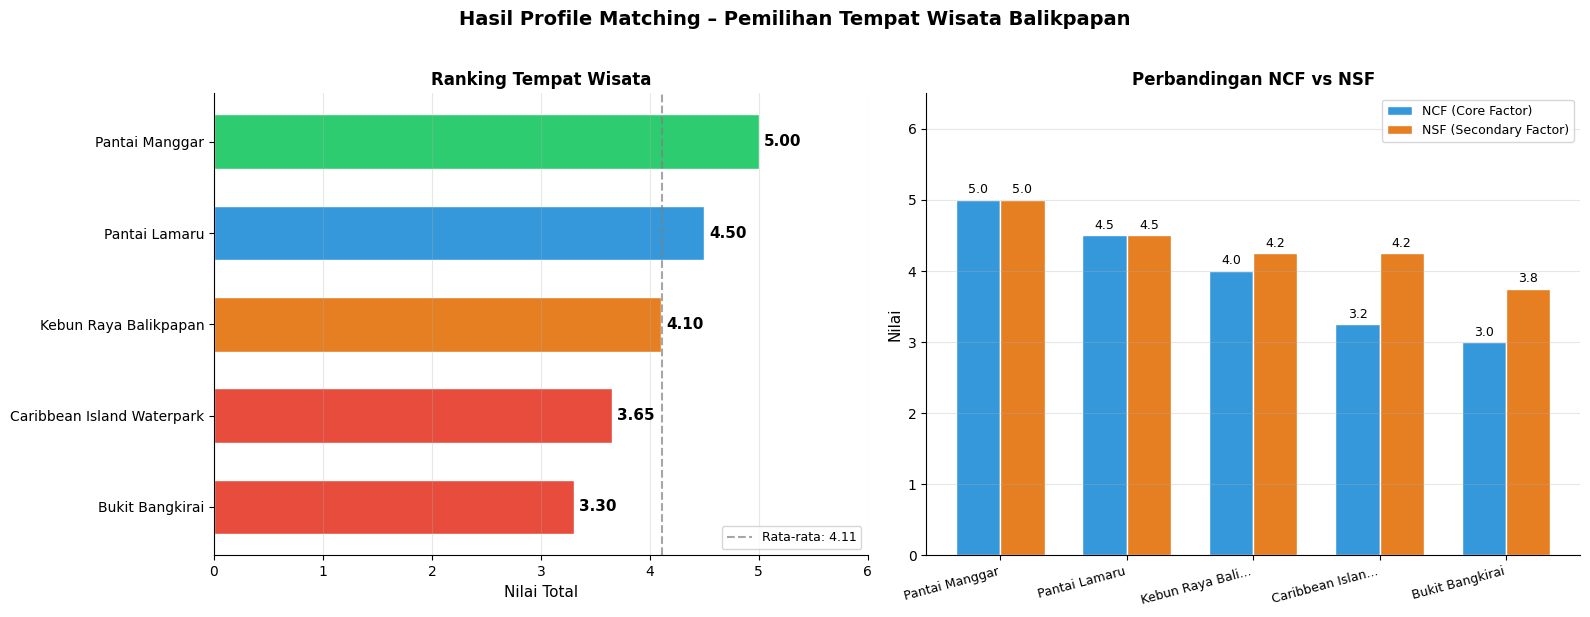

 Grafik berhasil ditampilkan dan disimpan


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Hasil Profile Matching – Pemilihan Tempat Wisata Balikpapan",
    fontsize=14, fontweight="bold", y=1.02
)

ax1 = axes[0]
colors = ["#2ecc71" if i == 0 else "#3498db" if i == 1
          else "#e67e22" if i == 2 else "#e74c3c"
          for i in range(len(df_hasil))]

bars = ax1.barh(
    df_hasil["Tempat Wisata"][::-1],
    df_hasil["Nilai Total"][::-1],
    color=colors[::-1],
    edgecolor="white",
    height=0.6
)

for bar, val in zip(bars, df_hasil["Nilai Total"][::-1]):
    ax1.text(
        bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}", va="center", fontsize=11, fontweight="bold"
    )

ax1.set_xlabel("Nilai Total", fontsize=11)
ax1.set_title("Ranking Tempat Wisata", fontsize=12, fontweight="bold")
ax1.set_xlim(0, 6)
ax1.axvline(x=df_hasil["Nilai Total"].mean(), color="gray",
            linestyle="--", alpha=0.7, label=f"Rata-rata: {df_hasil['Nilai Total'].mean():.2f}")
ax1.legend(fontsize=9)
ax1.grid(axis="x", alpha=0.3)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

ax2 = axes[1]
x    = np.arange(len(df_hasil))
w    = 0.35
nama = [n[:15] + "..." if len(n) > 15 else n for n in df_hasil["Tempat Wisata"]]

b1 = ax2.bar(x - w/2, df_hasil["NCF"], w, label="NCF (Core Factor)",
             color="#3498db", edgecolor="white")
b2 = ax2.bar(x + w/2, df_hasil["NSF"], w, label="NSF (Secondary Factor)",
             color="#e67e22", edgecolor="white")

for bar in b1:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9)
for bar in b2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9)

ax2.set_xticks(x)
ax2.set_xticklabels(nama, rotation=15, ha="right", fontsize=9)
ax2.set_ylabel("Nilai", fontsize=11)
ax2.set_title("Perbandingan NCF vs NSF", fontsize=12, fontweight="bold")
ax2.set_ylim(0, 6.5)
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.3)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("hasil_profile_matching.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Grafik berhasil ditampilkan dan disimpan")

### Langkah 8 — Rekap Lengkap Semua Tabel


In [8]:
df_rekap = df_gap.join(df_bobot).join(
    df_hasil.set_index("Tempat Wisata")[["NCF", "NSF", "Nilai Total"]]
)

print("📋 TABEL REKAP LENGKAP PROFILE MATCHING")
print("=" * 90)
print(df_rekap.to_string())
print()
print("📌 Keterangan:")
print("   GAP      = Profil Ideal - Nilai Tempat Wisata")
print("   Bobot    = Konversi GAP ke bobot nilai (tabel standar)")
print("   NCF      = Rata-rata bobot Core Factor (Biaya, Fasilitas)")
print("   NSF      = Rata-rata bobot Secondary Factor (Jenis, Jarak)")
print("   N.Total  = (60% × NCF) + (40% × NSF)")

📋 TABEL REKAP LENGKAP PROFILE MATCHING
                            GAP Biaya  GAP Fasilitas  GAP Jenis  GAP Jarak  Bobot Biaya  Bobot Fasilitas  Bobot Jenis  Bobot Jarak   NCF   NSF  Nilai Total
Tempat Wisata                                                                                                                                              
Pantai Manggar                      0              0          0          0            5              5.0          5.0          5.0  5.00  5.00         5.00
Kebun Raya Balikpapan              -1             -1          1         -1            4              4.0          4.5          4.0  4.00  4.25         4.10
Pantai Lamaru                       0             -1          0         -1            5              4.0          5.0          4.0  4.50  4.50         4.50
Bukit Bangkirai                    -2             -2          1         -2            3              3.0          4.5          3.0  3.00  3.75         3.30
Caribbean Island Waterpar

---

## 5. Kesimpulan

### Rangkuman Alur Metode Profile Matching

| Langkah | Proses | Rumus |
|---------|--------|-------|
| 1 | Tentukan **profil ideal** wisatawan | — |
| 2 | Kumpulkan **data nilai** tiap obyek wisata | — |
| 3 | Hitung **GAP** | $GAP = \text{Profil Wisatawan} - \text{Profil Ideal}$ |
| 4 | Konversi GAP ke **bobot nilai** | Tabel Kusrini (2007) |
| 5 | Hitung **Core Factor** | $NCF = \frac{\sum NC}{\sum IC}$ |
| 6 | Hitung **Secondary Factor** | $NSF = \frac{\sum NS}{\sum IS}$ |
| 7 | Hitung **Nilai Total** | $N = (60\% \times NCF) + (40\% \times NSF)$ |
| 8 | Urutkan → **Ranking** | Nilai terbesar = rekomendasi terbaik |

---

> **Referensi:** Muhaimin, F.A., dkk. (2018). *Sistem Pendukung Keputusan Pemilihan Obyek Wisata
> di Kota Balikpapan Menggunakan Metode Profile Matching*.
> JURTI Vol.2 No.1. DOI: 10.30872/jurti.v2i1.1427
